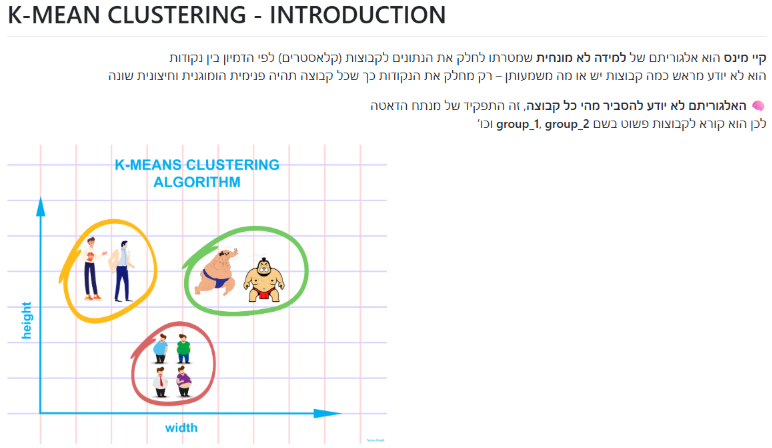

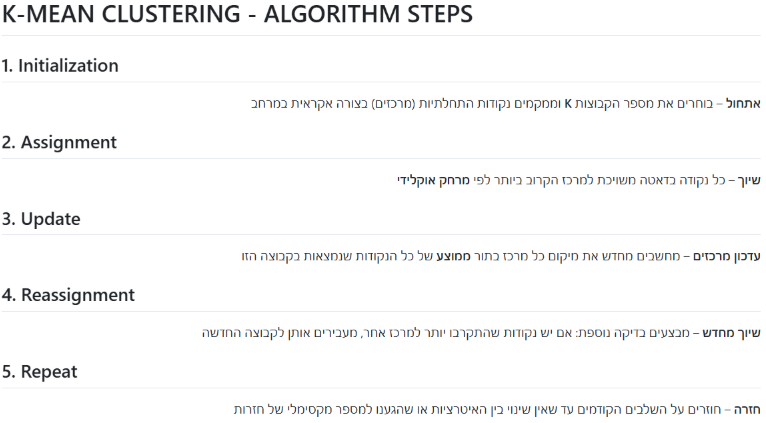

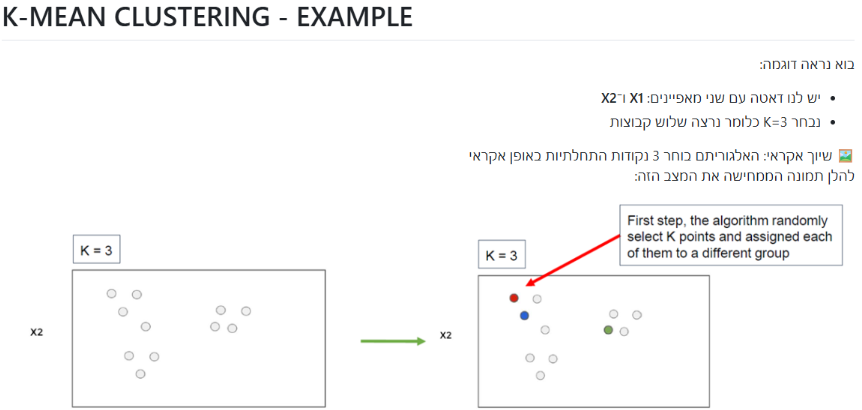

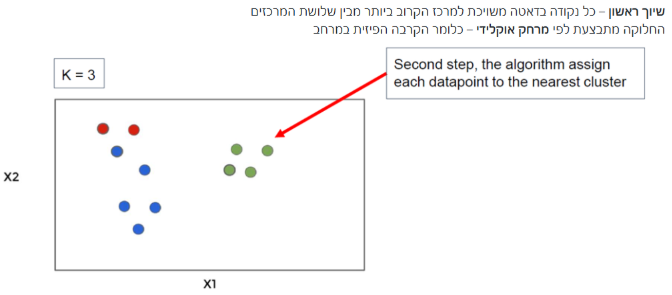

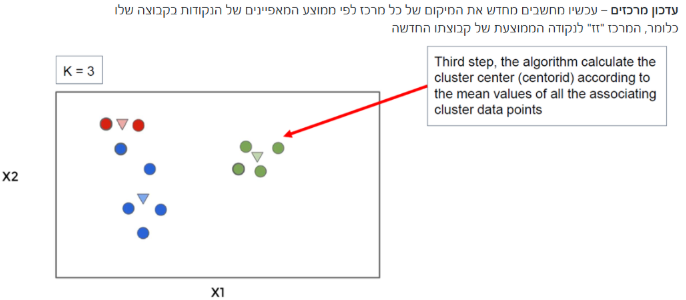

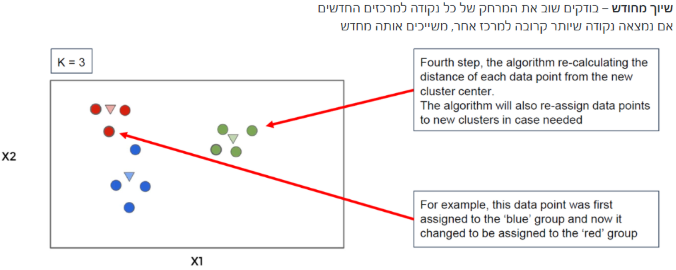

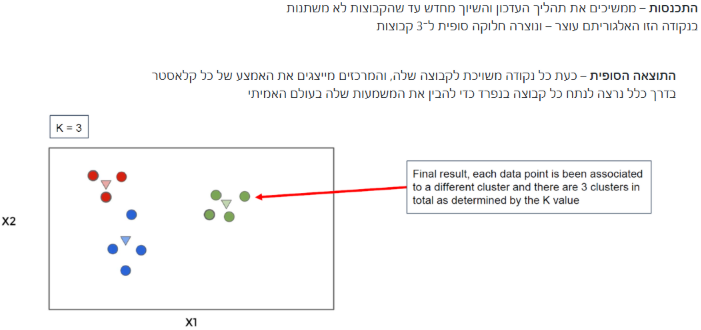

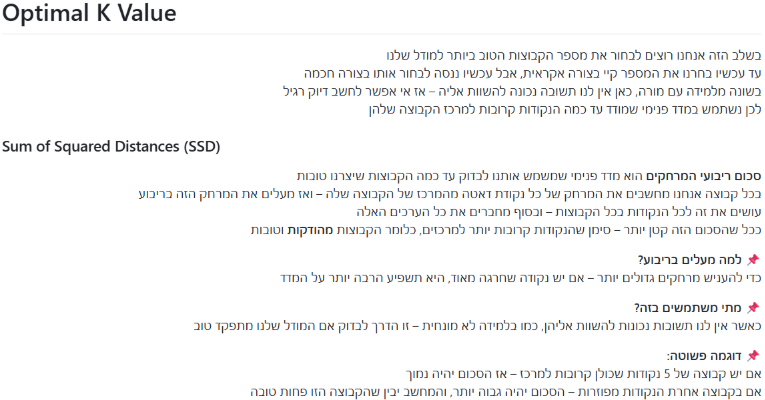

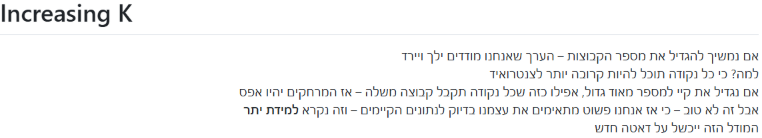

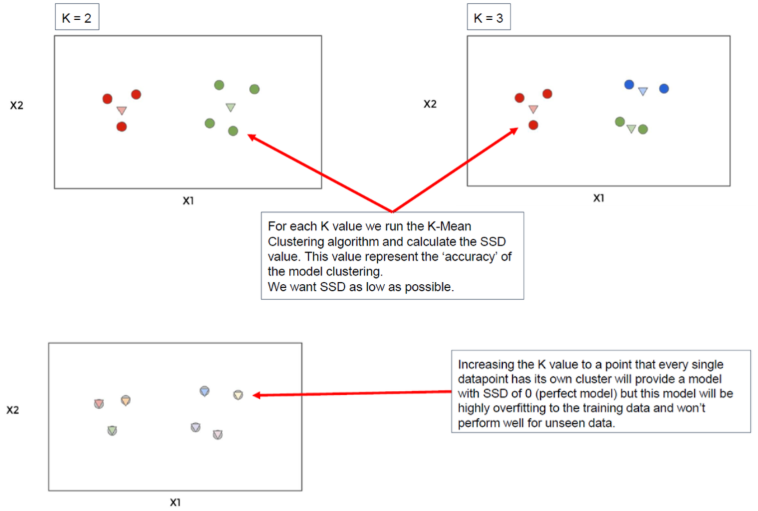

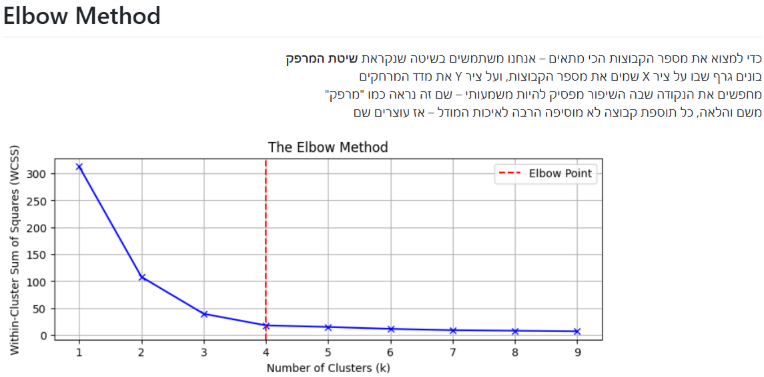

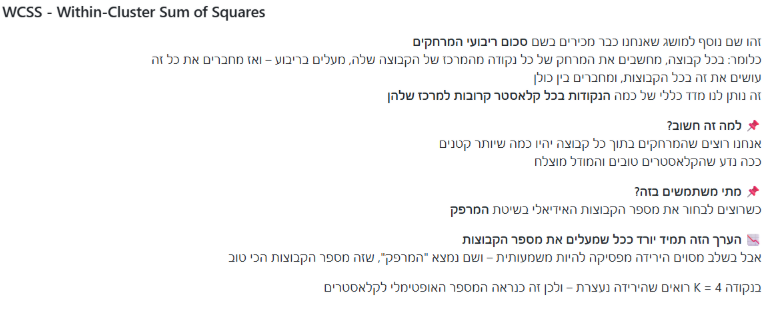

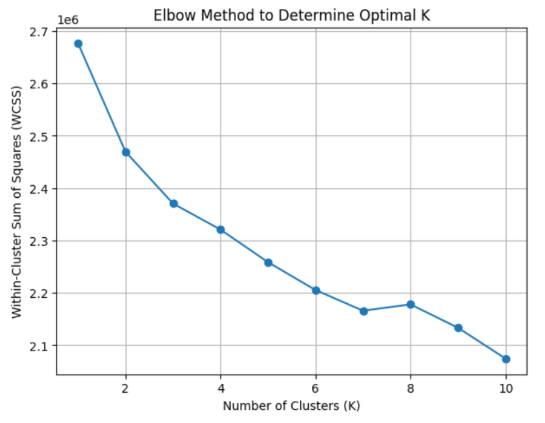

In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
  
# Load the data
df = pd.read_csv("bank-full.csv")

df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.describe().T
df['job'].unique()

scaler = StandardScaler()
features = df_encoded.columns
df_scaled = pd.DataFrame(scaler.fit_transform(df_encoded), columns=features)
df_scaled

k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df_scaled)

# df['cluster'].unique()
df['cluster']
# df
cluster_sizes = df['cluster'].value_counts()
print("\nCluster sizes:")
print(cluster_sizes)

print("\nPercentage of total:")
print(round(cluster_sizes / len(df) * 100, 2))

print(f'sklearn -> {sklearn.__version__}')
print(f'pandas -> {pd.__version__}')
print(f'numpy -> {np.__version__}')

# research groups
numerical_cols = ['age', 'duration', 'campaign', 'pdays', 'previous',
                  'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                  'euribor3m', 'nr.employed']
cluster_means = df.groupby('cluster')[numerical_cols].mean()
print("\nNumerical feature means by cluster:")
print(cluster_means)


Cluster sizes:
cluster
1    12204
4    12027
2     8755
0     6685
3     1517
Name: count, dtype: int64

Percentage of total:
cluster
1    29.63
4    29.20
2    21.26
0    16.23
3     3.68
Name: count, dtype: float64
sklearn -> 1.7.2
pandas -> 2.3.3
numpy -> 2.3.5

Numerical feature means by cluster:
               age    duration  campaign       pdays  previous  emp.var.rate  \
cluster                                                                        
0        38.857741  271.384892  3.235752  999.000000  0.000000      1.400000   
1        40.305310  256.168387  2.808096  999.000000  0.000082      1.201180   
2        41.055511  232.639634  2.459166  999.000000  0.079497      0.786294   
3        41.848385  321.363217  1.822017    7.323665  1.665788     -2.095320   
4        39.406003  263.863640  2.125135  999.000000  0.324270     -2.024686   

         cons.price.idx  cons.conf.idx  euribor3m  nr.employed  
cluster                                                         
0     

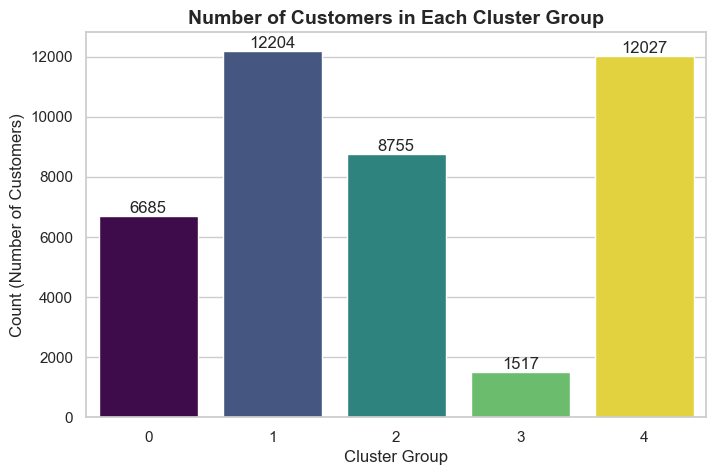

In [2]:
# Set a nice style for the graph
sns.set_theme(style="whitegrid")

# Create the figure and define its size
plt.figure(figsize=(8, 5))

# Create a bar plot counting how many data points are in each cluster
# We use x='cluster' so it counts the groups on the X-axis
ax = sns.countplot(data=df, x='cluster', hue='cluster', palette='viridis', legend=False)
# Add labels on top of each bar so you can see the exact count easily
for container in ax.containers:
    ax.bar_label(container)

# Add titles and labels to make the graph easy to read
plt.title('Number of Customers in Each Cluster Group', fontsize=14, fontweight='bold')
plt.xlabel('Cluster Group', fontsize=12)
plt.ylabel('Count (Number of Customers)', fontsize=12)

# Display the graph on your screen
plt.show()

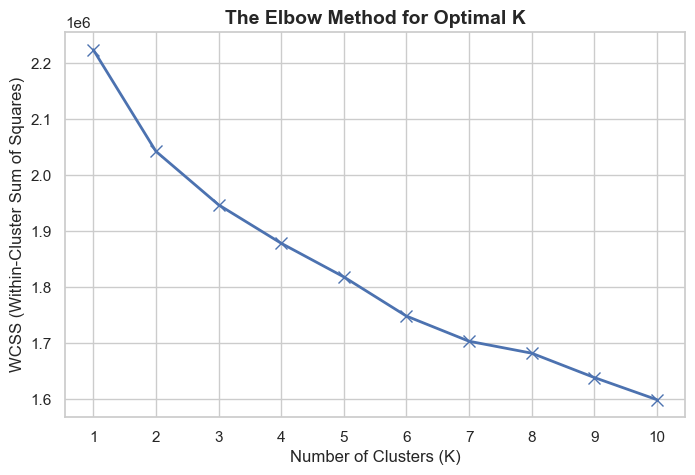

In [3]:
# 1. Create an empty list to store the WCSS values
wcss = []

# 2. Run KMeans for 1 to 10 clusters
# We use a loop to try different values of k
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    # .inertia_ gives the WCSS for that model
    wcss.append(kmeans.inertia_)

# Set a nice style for the graph
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# 3. Plot the Elbow Graph
# We use a line plot with blue dots ('bx-') to show the trend
plt.plot(range(1, 11), wcss, 'bx-', linewidth=2, markersize=8)

# 4. Add titles and labels
plt.title('The Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)

# Make sure all numbers from 1 to 10 show up on the X-axis
plt.xticks(range(1, 11))

# Display the graph
plt.show()